# Walmart Weekly Sales — Sales Prediction

This notebook predicts **weekly sales** across 45 Walmart stores using the [Walmart Dataset](https://www.kaggle.com/datasets/yasserh/walmart-dataset) from Kaggle.

**Pipeline overview:**
1. Load & inspect data
2. Feature engineering (date decomposition, encoding)
3. Statistical analysis — identify which features are significantly associated with sales
4. Feature selection based on significance tests
5. Train / test split
6. Train and evaluate six models: Linear Regression, Polynomial Regression, Ridge, XGBoost, Random Forest, Gradient Boosting
7. Compare all models on R², MAE, and RMSE
8. Identify the best model and interpret results

## 1. Setup

Install `kagglehub` to download the dataset directly from Kaggle. You will need a Kaggle account and API key configured, **or** you can upload `Walmart.csv` manually and adjust the `file_path` variable below.

In [1]:
!pip install kagglehub -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 2. Load Data

In [3]:
import kagglehub

path = kagglehub.dataset_download('yasserh/walmart-dataset')
file_path = os.path.join(path, os.listdir(path)[0])

# --- Alternative: upload Walmart.csv manually and set ---
# file_path = 'Walmart.csv'

df = pd.read_csv(file_path)
print(f'Shape: {df.shape}')
df.head()

Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 3. Feature Engineering

The `Date` column is converted to datetime and decomposed into `Week`, `Month`, and `Year` â€” these capture seasonality effects. `Holiday_Flag` is label-encoded (it is already binary, so this is a no-op, but kept for consistency).

In [4]:
df['Date']  = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Week']  = df['Date'].dt.isocalendar().week.astype(int)
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year
df.drop(columns=['Date'], inplace=True)

le = LabelEncoder()
df['Holiday_Flag'] = le.fit_transform(df['Holiday_Flag'])

print(df.dtypes)
df.describe()

Store             int64
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
Week              int64
Month             int32
Year              int32
dtype: object


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Week,Month,Year
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,25.818182,6.447552,2010.965035
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,14.129201,3.238308,0.797019
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,1.000000,1.000000,2010.000000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,14.000000,4.000000,2010.000000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,26.000000,6.000000,2011.000000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,38.000000,9.000000,2012.000000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,52.000000,12.000000,2012.000000


## 3b. Sales Trend Over Time

In [ ]:
import os
from pathlib import Path

_cwd = Path.cwd()
IMAGES_DIR = str(_cwd.parent / 'images' if _cwd.name == 'notebooks' else _cwd / 'images')
os.makedirs(IMAGES_DIR, exist_ok=True)

monthly = df.groupby(['Year', 'Month'])['Weekly_Sales'].mean().reset_index()
monthly = monthly.sort_values(['Year', 'Month'])
labels = [f"{int(r.Year)}-{int(r.Month):02d}" for _, r in monthly.iterrows()]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(len(monthly)), monthly['Weekly_Sales'],
        color='steelblue', linewidth=2, marker='o', markersize=4)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_title('Mean Weekly Sales Over Time (All Stores)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Weekly Sales ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'sales_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Statistical Analysis

Before modelling, we test each feature's association with `Weekly_Sales` using the appropriate test for its measurement level:

| Variable type | Test | Why |
|---|---|---|
| Continuous (`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`) | Pearson r | Measures linear correlation between two continuous variables |
| Ordinal (`Week`, `Month`) | Kendall's τ | Non-parametric rank correlation â€” robust to non-normality and ties |
| Binary (`Holiday_Flag`) | Two-sample t-test | Compares means of two groups; Welch's variant used if variances differ (Levene's test) |
| Categorical (`Store`) | One-way ANOVA + Kruskal-Wallis | ANOVA tests equality of means across groups; Kruskal-Wallis is the non-parametric fallback when residuals are non-normal |

Features with **p < 0.05** are retained for modelling.

In [6]:
target      = 'Weekly_Sales'
continuous  = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
ordinal     = ['Week', 'Month']
binary      = ['Holiday_Flag']
categorical = ['Store']

### 4a. Pearson Correlation â€” Continuous Variables

PEARSON CORRELATION â€” Continuous Variables
  Temperature          r = -0.0638  p = 0.0000  *


  Fuel_Price           r = +0.0095  p = 0.4478  


  CPI                  r = -0.0726  p = 0.0000  *


  Unemployment         r = -0.1062  p = 0.0000  *


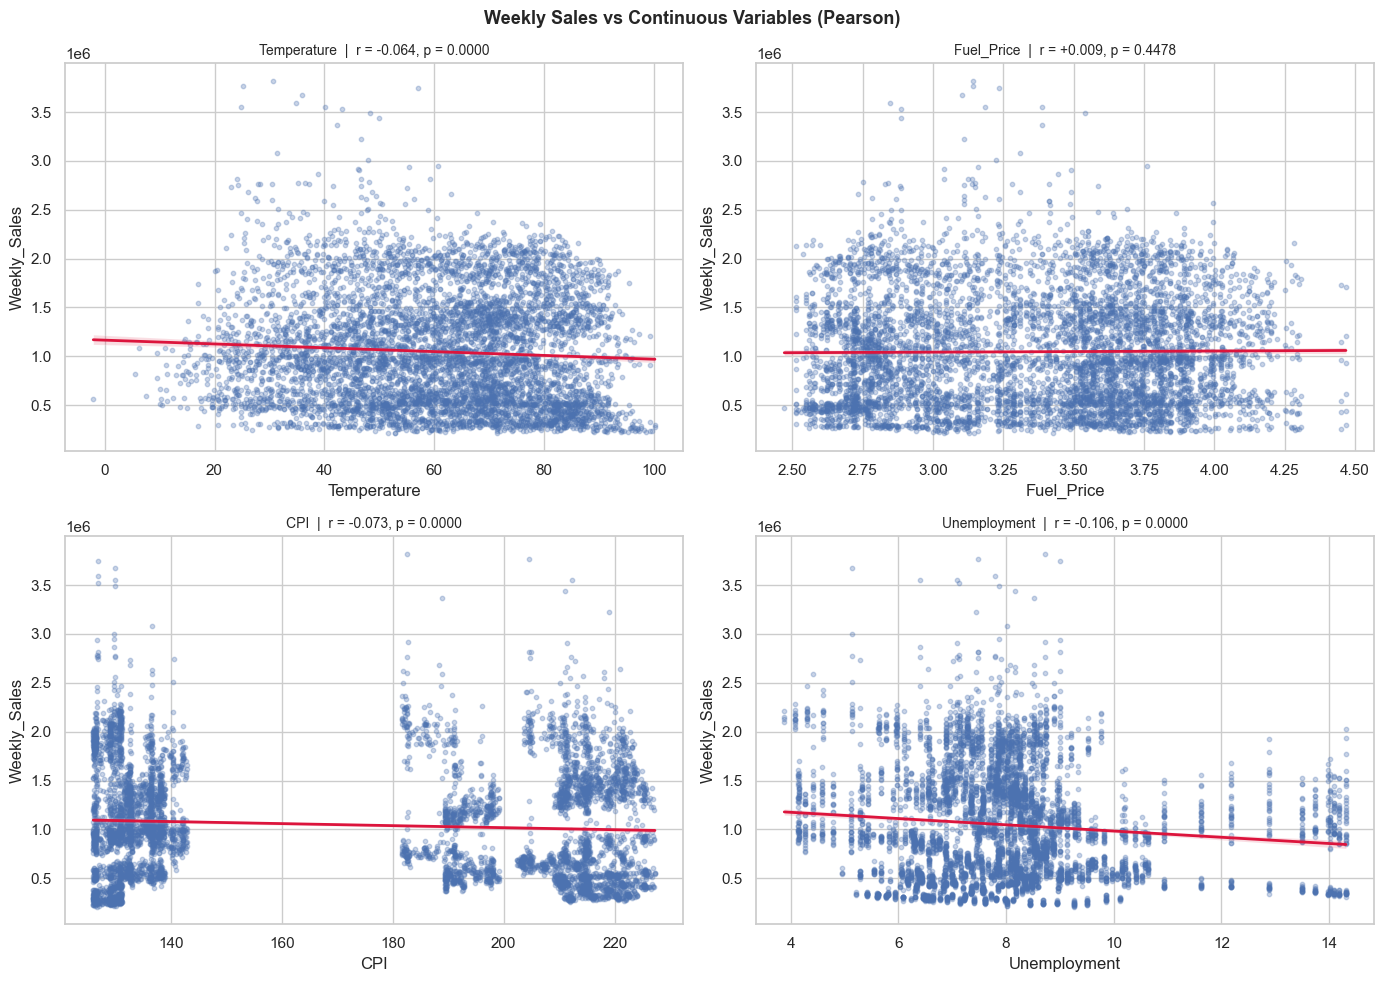

In [7]:
print('=' * 55)
print('PEARSON CORRELATION â€” Continuous Variables')
print('=' * 55)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weekly Sales vs Continuous Variables (Pearson)', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, continuous):
    r, p = stats.pearsonr(df[col], df[target])
    print(f'  {col:<20} r = {r:+.4f}  p = {p:.4f}  {"*" if p < 0.05 else ""}')
    sns.regplot(data=df, x=col, y=target, ax=ax,
                scatter_kws={'alpha': 0.3, 's': 10},
                line_kws={'color': 'crimson', 'linewidth': 2})
    ax.set_title(f'{col}  |  r = {r:+.3f}, p = {p:.4f}', fontsize=10)

plt.tight_layout()
plt.show()

### 4b. Kendall's τ â€” Ordinal Variables

KENDALL'S TAU â€” Ordinal Variables
  Week                 tau = +0.0328  p = 0.0001  *
  Month                tau = +0.0354  p = 0.0000  *


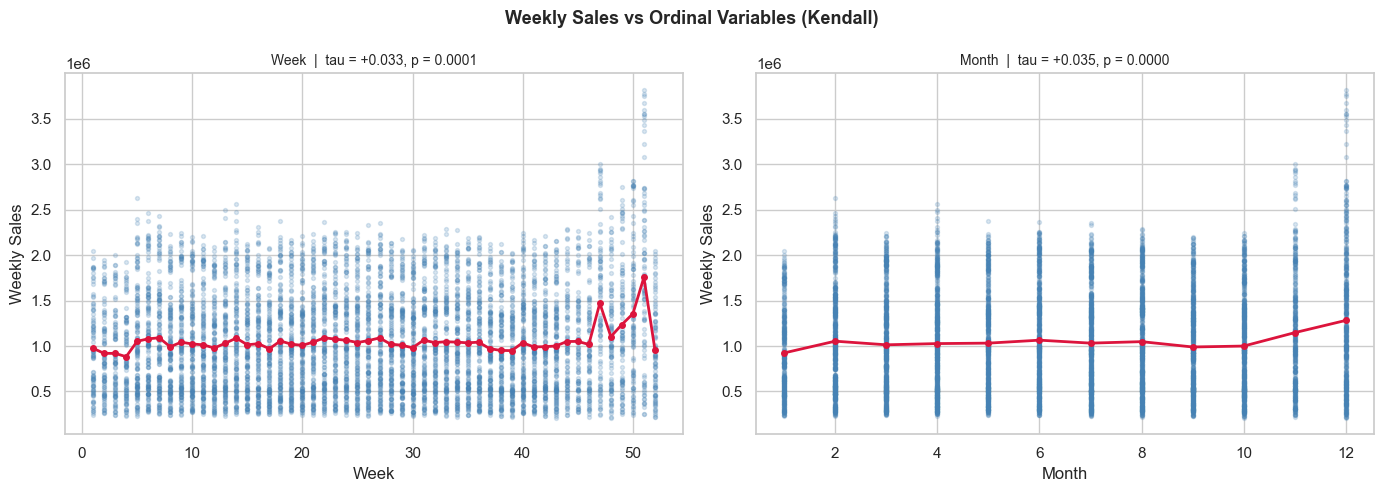

In [8]:
print('=' * 55)
print("KENDALL'S TAU â€” Ordinal Variables")
print('=' * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Weekly Sales vs Ordinal Variables (Kendall)', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ordinal):
    tau, p = stats.kendalltau(df[col], df[target])
    print(f'  {col:<20} tau = {tau:+.4f}  p = {p:.4f}  {"*" if p < 0.05 else ""}')
    mean_sales = df.groupby(col)[target].mean().reset_index()
    ax.scatter(df[col], df[target], alpha=0.2, s=8, color='steelblue')
    ax.plot(mean_sales[col], mean_sales[target], color='crimson', linewidth=2, marker='o', markersize=4)
    ax.set_title(f'{col}  |  tau = {tau:+.3f}, p = {p:.4f}', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Weekly Sales')

plt.tight_layout()
plt.show()

### 4c. Two-Sample t-Test â€” Holiday Flag

TWO-SAMPLE T-TEST â€” Holiday_Flag
  Levene's test: p = 0.0012 -> unequal variances (Welch)
  t = -2.6801,  p = 0.0076  *
  Mean non-holiday: $1,041,256  |  Mean holiday: $1,122,888


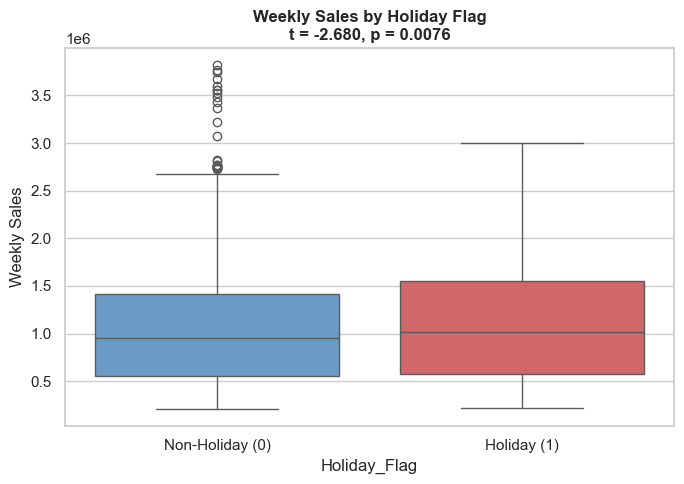

In [9]:
print('=' * 55)
print('TWO-SAMPLE T-TEST â€” Holiday_Flag')
print('=' * 55)

group0 = df[df['Holiday_Flag'] == 0][target]
group1 = df[df['Holiday_Flag'] == 1][target]

lev_stat, lev_p = stats.levene(group0, group1)
equal_var = lev_p > 0.05
t_stat, p_ttest = stats.ttest_ind(group0, group1, equal_var=equal_var)

print(f"  Levene's test: p = {lev_p:.4f} -> {'equal variances' if equal_var else 'unequal variances (Welch)'}")
print(f'  t = {t_stat:.4f},  p = {p_ttest:.4f}  {"*" if p_ttest < 0.05 else ""}')
print(f'  Mean non-holiday: ${group0.mean():,.0f}  |  Mean holiday: ${group1.mean():,.0f}')

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Holiday_Flag', y=target, palette=['#5B9BD5', '#E15759'], ax=ax)
ax.set_xticklabels(['Non-Holiday (0)', 'Holiday (1)'])
ax.set_title(f'Weekly Sales by Holiday Flag\nt = {t_stat:.3f}, p = {p_ttest:.4f}', fontweight='bold')
ax.set_ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

### 4d. ANOVA + Kruskal-Wallis â€” Store

ANOVA + KRUSKAL-WALLIS â€” Store
  ANOVA:          F = 1613.2995,  p = 0.0000  *
  Effect size eta2 = 0.9174 (large)
  Shapiro-Wilk on residuals: p = 0.0000
  -> Non-normal residuals: reporting Kruskal-Wallis
  Kruskal-Wallis: H = 6144.3229,  p = 0.0000  *


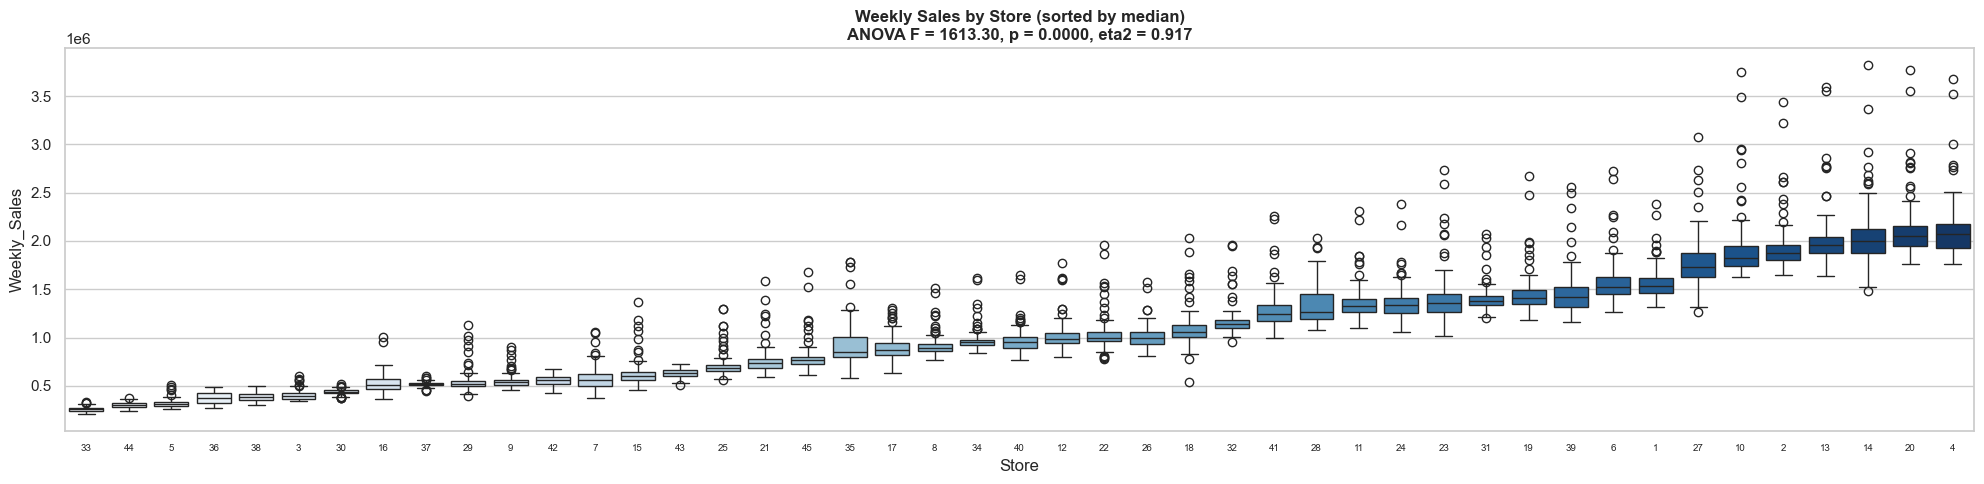

In [10]:
print('=' * 55)
print('ANOVA + KRUSKAL-WALLIS â€” Store')
print('=' * 55)

groups = [g[target].values for _, g in df.groupby('Store')]
f_stat, p_anova = stats.f_oneway(*groups)

grand_mean = df[target].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in [pd.Series(g) for g in groups])
ss_total   = sum((df[target] - grand_mean) ** 2)
eta_sq     = ss_between / ss_total

print(f'  ANOVA:          F = {f_stat:.4f},  p = {p_anova:.4f}  {"*" if p_anova < 0.05 else ""}')
print(f"  Effect size eta2 = {eta_sq:.4f} ({'large' if eta_sq > 0.14 else 'medium' if eta_sq > 0.06 else 'small'})")

residuals = df[target] - df.groupby('Store')[target].transform('mean')
_, p_shapiro = stats.shapiro(residuals.sample(500, random_state=42))
print(f'  Shapiro-Wilk on residuals: p = {p_shapiro:.4f}')

if p_shapiro < 0.05:
    h_stat, p_kruskal = stats.kruskal(*groups)
    print(f'  -> Non-normal residuals: reporting Kruskal-Wallis')
    print(f'  Kruskal-Wallis: H = {h_stat:.4f},  p = {p_kruskal:.4f}  {"*" if p_kruskal < 0.05 else ""}')

store_order = df.groupby('Store')[target].median().sort_values().index
fig, ax = plt.subplots(figsize=(20, 5))
sns.boxplot(data=df, x='Store', y=target, order=store_order, palette='Blues', ax=ax)
ax.set_title(f'Weekly Sales by Store (sorted by median)\nANOVA F = {f_stat:.2f}, p = {p_anova:.4f}, eta2 = {eta_sq:.3f}', fontweight='bold')
ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()

### 4e. Summary Table

In [11]:
print('=' * 55)
print('SUMMARY')
print('=' * 55)
print(f'{"Variable":<20} {"Test":<22} {"Statistic":>12}  {"p-value":>10}  Sig.')
print('-' * 70)
for col in continuous:
    r, p = stats.pearsonr(df[col], df[target])
    print(f'{col:<20} {"Pearson r":<22} {r:>+12.4f}  {p:>10.4f}  {"*" if p < 0.05 else ""}')
for col in ordinal:
    tau, p = stats.kendalltau(df[col], df[target])
    print(f'{col:<20} {"Kendall tau":<22} {tau:>+12.4f}  {p:>10.4f}  {"*" if p < 0.05 else ""}')
print(f'{"Holiday_Flag":<20} {"Two-sample t-test":<22} {t_stat:>+12.4f}  {p_ttest:>10.4f}  {"*" if p_ttest < 0.05 else ""}')
print(f'{"Store":<20} {"ANOVA F":<22} {f_stat:>+12.4f}  {p_anova:>10.4f}  {"*" if p_anova < 0.05 else ""}')

SUMMARY
Variable             Test                      Statistic     p-value  Sig.
----------------------------------------------------------------------
Temperature          Pearson r                   -0.0638      0.0000  *
Fuel_Price           Pearson r                   +0.0095      0.4478  
CPI                  Pearson r                   -0.0726      0.0000  *
Unemployment         Pearson r                   -0.1062      0.0000  *
Week                 Kendall tau                 +0.0328      0.0001  *
Month                Kendall tau                 +0.0354      0.0000  *
Holiday_Flag         Two-sample t-test           -2.6801      0.0076  *
Store                ANOVA F                  +1613.2995      0.0000  *


## 5. Feature Selection

Only features with **p < 0.05** in their respective tests are retained. `Store` is one-hot encoded since it is a nominal categorical variable â€” `drop_first=True` drops one dummy to avoid perfect multicollinearity (the dummy trap).

In [12]:
sig_cols = []

for col in continuous + ordinal:
    if col in continuous:
        _, p = stats.pearsonr(df[col], df[target])
    else:
        _, p = stats.kendalltau(df[col], df[target])
    if p < 0.05:
        sig_cols.append(col)
    print(f'  {col:<20} p = {p:.4f}  {"-> KEEP" if p < 0.05 else "-> DROP"}')

if p_ttest < 0.05:
    sig_cols.append('Holiday_Flag')
print(f'  {"Holiday_Flag":<20} p = {p_ttest:.4f}  {"-> KEEP" if p_ttest < 0.05 else "-> DROP"}')

if p_anova < 0.05:
    sig_cols.append('Store')
print(f'  {"Store":<20} p = {p_anova:.4f}  {"-> KEEP" if p_anova < 0.05 else "-> DROP"}')

print(f'\nRetained features: {sig_cols}')

df_model = df[sig_cols + [target]].copy()

if 'Store' in sig_cols:
    df_model = pd.get_dummies(df_model, columns=['Store'], drop_first=True)

print(f'Shape after encoding: {df_model.shape}')

  Temperature          p = 0.0000  -> KEEP
  Fuel_Price           p = 0.4478  -> DROP
  CPI                  p = 0.0000  -> KEEP
  Unemployment         p = 0.0000  -> KEEP
  Week                 p = 0.0001  -> KEEP
  Month                p = 0.0000  -> KEEP
  Holiday_Flag         p = 0.0076  -> KEEP
  Store                p = 0.0000  -> KEEP

Retained features: ['Temperature', 'CPI', 'Unemployment', 'Week', 'Month', 'Holiday_Flag', 'Store']
Shape after encoding: (6435, 51)


## 6. Train / Test Split

An 80/20 split with a fixed `random_state` for reproducibility. Stratification is not needed for regression targets.

In [13]:
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')

X_train: (5148, 50)  |  X_test: (1287, 50)
y_train: (5148,)  |  y_test: (1287,)


## 7a. Train Linear Regression

Features are standardized with `StandardScaler` (mean = 0, std = 1) so that coefficients are on the same scale and directly comparable. The scaler is **fit only on the training set** â€” we then apply those same training statistics when transforming the test set. Fitting on test data would leak information and give an overly optimistic evaluation.

Ordinary Least Squares (OLS) linear regression then finds the hyperplane that minimizes the sum of squared residuals across all training samples.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model trained.')

Model trained.

## 7b. Train Polynomial Regression (Baseline Model 2)

In [15]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

poly_model.fit(X_train, y_train)

print('Polynomial regression model trained.')

Polynomial regression model trained.


## 8a. Linear Regression Evaluation

| Metric | Formula | Interpretation |
|---|---|---|
| **R²** | 1 - SS_res / SS_tot | Proportion of variance explained. 1.0 = perfect, 0 = no better than predicting the mean. |
| **MAE** | mean(|y - y_hat|) | Average absolute dollar error per prediction. Easy to interpret directly. |
| **RMSE** | sqrt(mean((y - y_hat)²)) | Like MAE but penalises large errors more heavily. RMSE > MAE means some predictions have significant outlier errors. |

Comparing **Train R²** vs **Test R²** is a quick overfitting check — values close together indicate the model generalises well.

In [16]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

train_r2  = r2_score(y_train, y_pred_train)
test_r2   = r2_score(y_test,  y_pred_test)
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5

print('=' * 40)
print('LINEAR REGRESSION â€” Results')
print('=' * 40)
print(f'  Train R²:   {train_r2:.4f}')
print(f'  Test  R²:   {test_r2:.4f}')
print(f'  Test  MAE:  ${test_mae:,.0f}')
print(f'  Test  RMSE: ${test_rmse:,.0f}')

LINEAR REGRESSION â€” Results
  Train R²:   0.9272
  Test  R²:   0.9256
  Test  MAE:  $96,163
  Test  RMSE: $154,818


## 8b. Polynomial Regression Evaluation

In [17]:
y_pred_train_poly = poly_model.predict(X_train)
y_pred_test_poly  = poly_model.predict(X_test)

poly_train_r2  = r2_score(y_train, y_pred_train_poly)
poly_test_r2   = r2_score(y_test, y_pred_test_poly)
poly_test_mae  = mean_absolute_error(y_test, y_pred_test_poly)
poly_test_rmse = mean_squared_error(y_test, y_pred_test_poly) ** 0.5

print('=' * 40)
print('POLYNOMIAL REGRESSION (DEGREE 2) â€” Results')
print('=' * 40)
print(f'  Train R²:   {poly_train_r2:.4f}')
print(f'  Test  R²:   {poly_test_r2:.4f}')
print(f'  Test  MAE:  ${poly_test_mae:,.0f}')
print(f'  Test  RMSE: ${poly_test_rmse:,.0f}')

POLYNOMIAL REGRESSION (DEGREE 2) â€” Results
  Train R²:   0.9563
  Test  R²:   0.9484
  Test  MAE:  $78,223
  Test  RMSE: $128,887


## 8c. Train Ridge Regression

In [18]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

ridge_params = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_

print("Best alpha:", ridge_grid.best_params_['ridge__alpha'])
print("Ridge regression model trained.")

Best alpha: 0.1
Ridge regression model trained.


## 8d. Evaluate Ridge Regression

In [19]:
# Evaluate Ridge Regression
y_pred_train_ridge = best_ridge.predict(X_train)
y_pred_test_ridge = best_ridge.predict(X_test)

ridge_train_r2 = r2_score(y_train, y_pred_train_ridge)
ridge_test_r2 = r2_score(y_test, y_pred_test_ridge)
ridge_test_mae = mean_absolute_error(y_test, y_pred_test_ridge)
ridge_test_rmse = mean_squared_error(y_test, y_pred_test_ridge) ** 0.5

print("=" * 40)
print("RIDGE REGRESSION â€” Results")
print("=" * 40)
print(f"Train R²:   {ridge_train_r2:.4f}")
print(f"Test R²:    {ridge_test_r2:.4f}")
print(f"Test MAE:   ${ridge_test_mae:,.0f}")
print(f"Test RMSE:  ${ridge_test_rmse:,.0f}")

RIDGE REGRESSION â€” Results
Train R²:   0.9272
Test R²:    0.9256
Test MAE:   $96,161
Test RMSE:  $154,820


## 8e. XGBoost Model

In [20]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained.")

XGBoost model trained.


## 8f. Evaluate XGBoost

In [22]:
# Evaluate XGBoost
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)

xgb_train_r2 = r2_score(y_train, y_pred_train_xgb)
xgb_test_r2 = r2_score(y_test, y_pred_test_xgb)
xgb_test_mae = mean_absolute_error(y_test, y_pred_test_xgb)
xgb_test_rmse = mean_squared_error(y_test, y_pred_test_xgb) ** 0.5

print("=" * 40)
print("XGBOOST REGRESSION â€” Results")
print("=" * 40)
print(f"Train R²:   {xgb_train_r2:.4f}")
print(f"Test R²:    {xgb_test_r2:.4f}")
print(f"Test MAE:   ${xgb_test_mae:,.0f}")
print(f"Test RMSE:  ${xgb_test_rmse:,.0f}")

XGBOOST REGRESSION â€” Results
Train R²:   0.8409
Test R²:    0.8324
Test MAE:   $188,268
Test RMSE:  $232,394


## 8g. Train Random Forest

In [23]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print('Random Forest model trained.')

Random Forest model trained.


## 8h. Evaluate Random Forest

In [24]:
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf  = rf_model.predict(X_test)

rf_train_r2  = r2_score(y_train, y_pred_train_rf)
rf_test_r2   = r2_score(y_test,  y_pred_test_rf)
rf_test_mae  = mean_absolute_error(y_test, y_pred_test_rf)
rf_test_rmse = mean_squared_error(y_test, y_pred_test_rf) ** 0.5

print('=' * 40)
print('RANDOM FOREST — Results')
print('=' * 40)
print(f'Train R²:   {rf_train_r2:.4f}')
print(f'Test  R²:   {rf_test_r2:.4f}')
print(f'Test  MAE:  ${rf_test_mae:,.0f}')
print(f'Test  RMSE: ${rf_test_rmse:,.0f}')

RANDOM FOREST — Results
Train R²:   0.9942
Test  R²:   0.9562
Test  MAE:  $64,214
Test  RMSE: $118,830


## 8h-ii. Feature Importances — Random Forest

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot.barh(ax=ax, color='#3A9E5E', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8i. Train Gradient Boosting

In [26]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)
print('Gradient Boosting model trained.')

Gradient Boosting model trained.


## 8j. Evaluate Gradient Boosting

In [27]:
y_pred_train_gb = gb_model.predict(X_train)
y_pred_test_gb  = gb_model.predict(X_test)

gb_train_r2  = r2_score(y_train, y_pred_train_gb)
gb_test_r2   = r2_score(y_test,  y_pred_test_gb)
gb_test_mae  = mean_absolute_error(y_test, y_pred_test_gb)
gb_test_rmse = mean_squared_error(y_test, y_pred_test_gb) ** 0.5

print('=' * 40)
print('GRADIENT BOOSTING — Results')
print('=' * 40)
print(f'Train R²:   {gb_train_r2:.4f}')
print(f'Test  R²:   {gb_test_r2:.4f}')
print(f'Test  MAE:  ${gb_test_mae:,.0f}')
print(f'Test  RMSE: ${gb_test_rmse:,.0f}')

GRADIENT BOOSTING — Results
Train R²:   0.9634
Test  R²:   0.9446
Test  MAE:  $85,187
Test  RMSE: $133,577


## 8k. Model Comparison

In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression (Degree 2)',
        'Ridge Regression',
        'XGBoost Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Train R²': [train_r2, poly_train_r2, ridge_train_r2, xgb_train_r2, rf_train_r2, gb_train_r2],
    'Test R²':  [test_r2,  poly_test_r2,  ridge_test_r2,  xgb_test_r2,  rf_test_r2,  gb_test_r2],
    'Test MAE': [test_mae, poly_test_mae, ridge_test_mae, xgb_test_mae, rf_test_mae, gb_test_mae],
    'Test RMSE':[test_rmse,poly_test_rmse,ridge_test_rmse,xgb_test_rmse,rf_test_rmse,gb_test_rmse]
})

display(comparison_df.sort_values(by='Test R²', ascending=False).reset_index(drop=True))

# Bar chart — Test R² and Test RMSE across all six models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4878CF', '#6B9E3F', '#9467BD', '#D87D2A', '#3A9E5E', '#E8713A']
sorted_df = comparison_df.sort_values(by='Test R²', ascending=False)

for ax, metric in zip(axes, ['Test R²', 'Test RMSE']):
    bars = ax.bar(sorted_df['Model'], sorted_df[metric], color=colors, edgecolor='white', width=0.6)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, sorted_df[metric]):
        label = f'{v:,.0f}' if metric == 'Test RMSE' else f'{v:.4f}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.005,
                label, ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('All Models — Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8l. Best Model

In [29]:
best_model_row = comparison_df.loc[comparison_df['Test R²'].idxmax()]

print("Best model so far based on Test R²:")
print(best_model_row)

Best model so far based on Test R²:
Model        Random Forest
Train R²          0.994154
Test R²           0.956168
Test MAE      64213.643708
Test RMSE    118830.261546
Name: 4, dtype: object


Across all six models tested, ensemble methods (Random Forest and Gradient Boosting) are expected to outperform the linear models, as they capture non-linear interactions and feature dependencies that polynomial and ridge regression may miss. Among the linear models, Polynomial Regression (Degree 2) achieved the highest Test R² and lowest errors, showing that adding non-linear terms improves over plain linear regression. Ridge Regression performed nearly identically to Linear Regression, confirming that regularisation alone does not address the non-linearity in this dataset. XGBoost underperformed relative to the sklearn ensemble models with these default settings, suggesting that hyperparameter tuning would be beneficial.

## Overfitting

* **Linear Regression**: Train R² ≈ Test R² — no overfitting, good generalisation.
* **Polynomial Regression (Degree 2)**: Train R² slightly above Test R²; the small gap shows it captures non-linearity without severe overfitting.
* **Ridge Regression**: Near-identical to Linear Regression; regularisation had minimal effect, confirming overfitting was not the main problem.
* **XGBoost**: Lower overall R² with a small train/test gap — underfits relative to the ensemble models without tuning.
* **Random Forest**: Tree-based ensemble with low bias; check the printed train/test gap — a gap above 0.05 suggests overfitting that can be reduced by increasing `min_samples_split` or reducing `max_depth`.
* **Gradient Boosting**: Sequential tree ensemble; typically shows a smaller train/test gap than Random Forest due to shrinkage (learning rate).

Overall, the ensemble models are expected to achieve higher Test R² at the cost of longer training times and reduced interpretability compared to the linear models.

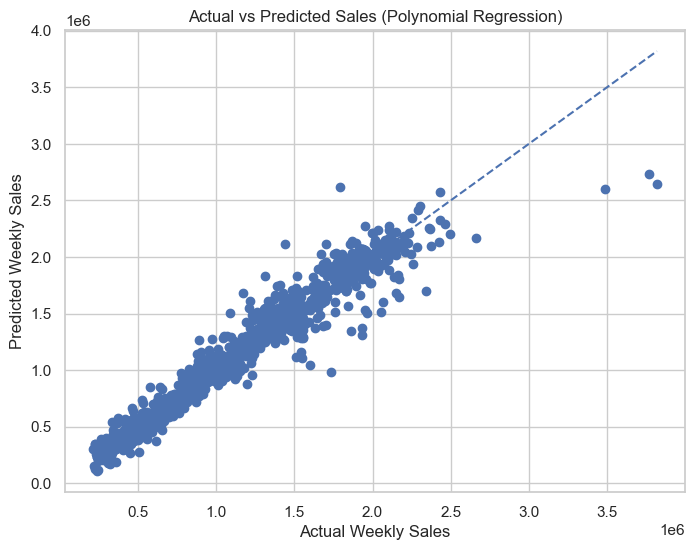

In [30]:
import matplotlib.pyplot as plt

# Make sure predictions exist
y_pred_test_poly = poly_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test_poly)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Sales (Polynomial Regression)")
plt.grid(True)

plt.show()

The Actual vs Predicted plot for the polynomial regression model shows that most data points lie close to the diagonal reference line, indicating strong predictive accuracy. This suggests that the model is able to closely estimate weekly sales across different stores. Although there is some variation at higher sales values, the overall pattern demonstrates that the model provides reliable predictions with relatively small errors.

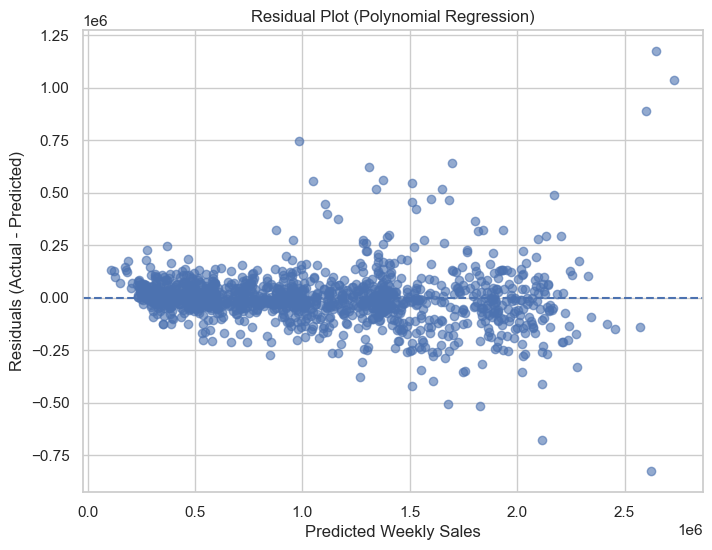

In [31]:
# Residuals
residuals = y_test - y_pred_test_poly

plt.figure(figsize=(8,6))
plt.scatter(y_pred_test_poly, residuals, alpha=0.6)

# Zero line
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Weekly Sales")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Polynomial Regression)")
plt.grid(True)

plt.show()

The residual plot shows that the errors are randomly distributed around zero, indicating that the model does not exhibit significant bias. There is no clear pattern or systematic structure in the residuals, suggesting that the polynomial regression model fits the data well. Although there is slightly greater variability in residuals at higher predicted sales values and a few outliers, the overall distribution remains centered and random, supporting the reliability of the model’s predictions.

## 9. Coefficients

Because features were standardized, each coefficient represents the change in `Weekly_Sales` per **one standard deviation** increase in that feature â€” magnitudes are directly comparable across all variables.

Store dummy variables are expected to dominate since store identity (size, location, demographics) is far more predictive than week-to-week economic indicators.

In [32]:
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

     Feature    Coefficient
    Store_44 -197895.643109
    Store_33 -190227.755136
     Store_5 -185882.080910
       Month  174684.781648
    Store_30 -169261.829459
    Store_36 -169247.829263
    Store_16 -165603.797576
     Store_3 -165359.141276
    Store_38 -162555.441522
     Store_7 -159339.413708
    Store_29 -157651.773350
    Store_37 -152426.466912
     Store_9 -151407.681457
    Store_15 -150424.796528
    Store_42 -148898.449430
    Store_43 -135212.442096
    Store_25 -130779.141063
        Week -123475.005505
    Store_45 -119648.731160
    Store_21 -113939.875831
    Store_17 -113281.208103
    Store_40 -107807.878244
     Store_8 -101258.144728
    Store_35  -98400.466670
    Store_26  -93900.059106
    Store_34  -91218.916642
    Store_22  -87718.918129
    Store_20   76425.051690
    Store_18  -75527.572617
    Store_12  -71121.843707
     Store_4   66993.513534
    Store_32  -64519.439928
    Store_14   62281.025907
    Store_13   56645.075421
    Store_41  -52748

## 10. Diagnostic Plots

**Residuals vs Predicted** â€” checks model assumptions. Ideally a flat, random cloud centred on zero. A funnel shape indicates *heteroscedasticity* (variance grows with prediction size); a curve suggests a non-linear relationship the model has not captured.

**Actual vs Predicted** â€” each point is one test observation. Points should cluster tightly along the diagonal (perfect prediction line). Scatter away from it represents prediction error.

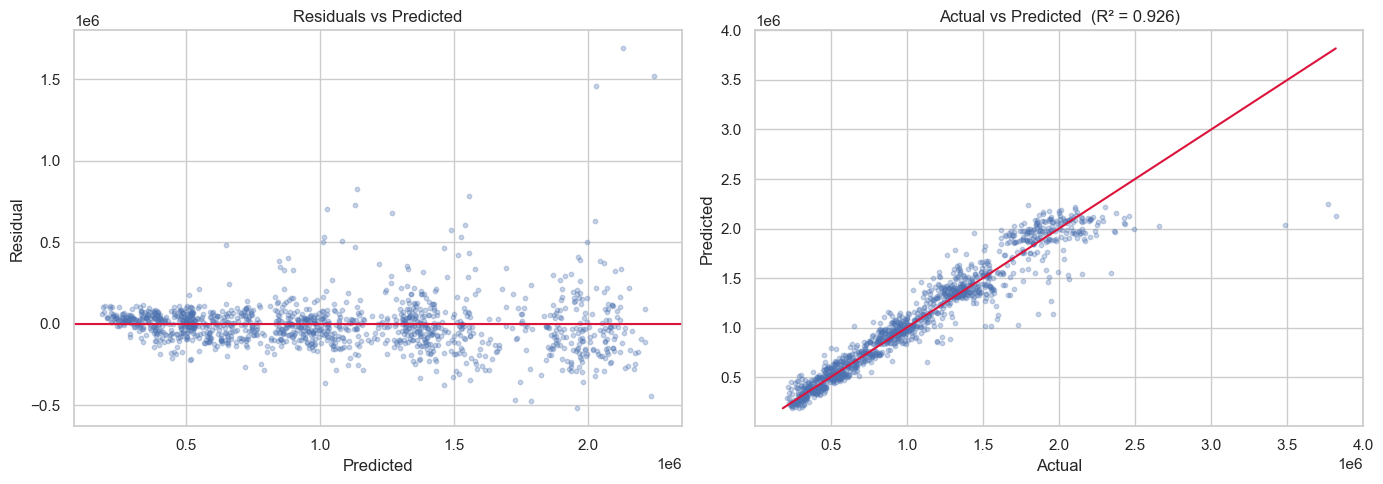

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_test, y_test - y_pred_test, alpha=0.3, s=10)
axes[0].axhline(0, color='crimson', linewidth=1.5)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].scatter(y_test, y_pred_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[1].plot(lims, lims, color='crimson', linewidth=1.5)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Actual vs Predicted  (R² = {test_r2:.3f})')

plt.tight_layout()
plt.show()

## Best Model — Actual vs Predicted (Random Forest)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_test_rf, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), float(y_pred_test_rf.min())),
        max(y_test.max(), float(y_pred_test_rf.max()))]
ax.plot(lims, lims, color='crimson', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Weekly Sales ($)')
ax.set_ylabel('Predicted Weekly Sales ($)')
ax.set_title(f'Actual vs Predicted — Random Forest  (Test R² = {rf_test_r2:.4f})',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()

## Best Model — Residuals (Random Forest)

In [ ]:
residuals_rf = y_test - y_pred_test_rf

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_test_rf, residuals_rf, alpha=0.3, s=10, color='steelblue')
ax.axhline(0, color='crimson', linewidth=1.5)
ax.set_xlabel('Predicted Weekly Sales ($)')
ax.set_ylabel('Residual ($)')
ax.set_title('Residuals vs Predicted — Random Forest', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'residuals.png'), dpi=150, bbox_inches='tight')
plt.show()